 Stock Price Prediction

In [ ]:
!pip install yfinance

Import libraries

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Stock Data

In [ ]:
stock = yf.download("TSLA", start="2020-01-01", end="2025-01-01")

stock.head()

/tmp/ipykernel_1242/168084968.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("TSLA", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


Target Variable

In [ ]:
print("Shape:", stock.shape)
stock.info()
stock.describe()

Shape: (1258, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1258 non-null   float64
 1   (High, TSLA)    1258 non-null   float64
 2   (Low, TSLA)     1258 non-null   float64
 3   (Open, TSLA)    1258 non-null   float64
 4   (Volume, TSLA)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,213.430922,218.283913,208.359167,213.482528,1.255368e+08
std,83.461475,85.396522,81.534697,83.626859,8.208891e+07
min,24.081333,26.990667,23.367332,24.980000,2.940180e+07
25%,173.882500,177.230003,170.044994,173.897499,7.601958e+07
50%,220.220001,225.369995,215.343338,220.933334,1.019894e+08
75%,259.932495,264.959175,254.450001,259.270004,1.453064e+08
max,479.859985,488.540009,457.510010,475.899994,9.140820e+08


In [ ]:
stock['Target'] = stock['Close'].shift(-1)

stock = stock.dropna()

stock.head()

Price,Close,High,Low,Open,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500,29.534000
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500,30.102667
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000,31.270666
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500,32.809334
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500,32.089333


Select Feature

In [ ]:
X = stock[['Open', 'High', 'Low', 'Volume']]

y = stock['Target']

Train-test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

Linear Regression Model

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


Prediction

In [ ]:
predictions = model.predict(X_test)

predictions[:5]

array([249.11003137, 246.59060014, 238.7229359 , 241.02338582,
       238.19385907])

Evaluate Model

In [ ]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE =", mae)
print("RMSE =", rmse)
print("R2 Score =", r2)

MAE = 6.938056768499431
RMSE = 10.125358726976748
R2 Score = 0.9795753492490631


Plot Actual vs Predicted Prices

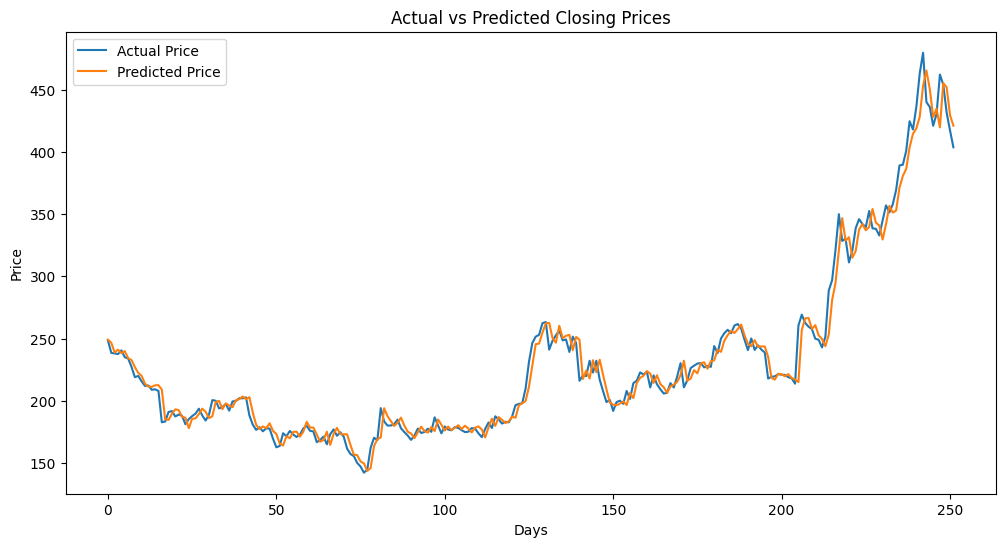

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price")

plt.plot(predictions, label="Predicted Price")

plt.title("Actual vs Predicted Closing Prices")

plt.xlabel("Days")

plt.ylabel("Price")

plt.legend()

plt.show()

Predict Next Day Price

In [ ]:
latest_data = X.iloc[-1:]

next_day_price = model.predict(latest_data)

print("Predicted Next Day Closing Price:")

print(next_day_price[0])

Predicted Next Day Closing Price:
421.14839279054286
